# Tweet Sentiment Classification using Naive Bayes

> **Project Revision Notice**<br>
> This project was originally created in May 2024 as part of my early NLP and machine learning learning journey. In May 2026, I revisited and rebuilt the project to improve the overall workflow, modelling pipeline, evaluation methodology, explainability, and business-oriented analysis.<br>
> You may refer to my GitHub repository for the old version of the notebook.

## ⚙️ Setup and Dataset Loading

In [1]:
# Import libraries
import os
import re
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)

In [2]:
# Locate Kaggle input files
for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/nlp-getting-started/sample_submission.csv
/kaggle/input/nlp-getting-started/train.csv
/kaggle/input/nlp-getting-started/test.csv


In [3]:
# Load train and test datasets
train_path = None
test_path = None

for dirname, _, filenames in os.walk("/kaggle/input"):
    for filename in filenames:
        file_path = os.path.join(dirname, filename)

        if filename == "train.csv":
            train_path = file_path
        elif filename == "test.csv":
            test_path = file_path

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (7613, 5)
Test shape: (3263, 4)


In [4]:
# Preview training data
train_df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation orders in California",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,1


In [5]:
# Preview test data
test_df.head()

,id,keyword,location,text
0,0,NaN,NaN,Just happened a terrible car crash
1,2,NaN,NaN,"Heard about #earthquake is different cities, stay safe everyone."
2,3,NaN,NaN,"there is a forest fire at spot pond, geese are fleeing across the street, I cannot save them all"
3,9,NaN,NaN,Apocalypse lighting. #Spokane #wildfires
4,11,NaN,NaN,Typhoon Soudelor kills 28 in China and Taiwan


In [6]:
# Check dataset information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7552 non-null   object
 2   location  5080 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB


In [7]:
# Check missing values
missing_values = train_df.isnull().sum().sort_values(ascending=False)
missing_values

location    2533
keyword       61
id             0
text           0
target         0
dtype: int64

In [8]:
# Check duplicate rows
duplicate_count = train_df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [9]:
# Check target distribution
target_distribution = train_df["target"].value_counts().sort_index()
target_percentage = train_df["target"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "count": target_distribution,
    "percentage": target_percentage.round(2)
})

target_summary

,count,percentage
target,,
0,4342,57.03
1,3271,42.97


### Dataset Overview

The dataset contains tweets from Kaggle’s Natural Language Processing with Disaster Tweets competition. Each tweet is labelled as either disaster-related or non-disaster-related.

The training dataset contains 7,613 rows and 5 columns, while the test dataset contains 3,263 rows and 4 columns.

The target variable is moderately balanced:

- Class 0: non-disaster tweets, representing 57.03% of the training data.
- Class 1: disaster-related tweets, representing 42.97% of the training data.

There are no duplicate rows in the training dataset. However, the `location` and `keyword` columns contain missing values. Since the `text` column has no missing values, the first modelling baseline will focus on tweet text only.

## 📊 Exploratory Data Analysis

In [10]:
# Import visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

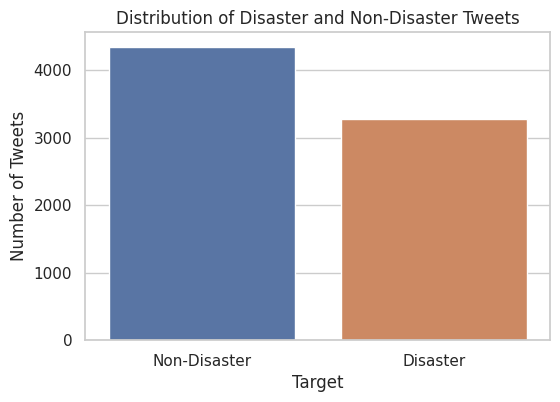

In [11]:
# Plot target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="target")
plt.title("Distribution of Disaster and Non-Disaster Tweets")
plt.xlabel("Target")
plt.ylabel("Number of Tweets")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

In [12]:
# Create tweet length features
train_df["text_length"] = train_df["text"].str.len()
train_df["word_count"] = train_df["text"].str.split().str.len()

train_df[["text_length", "word_count"]].describe()

,text_length,word_count
count,7613.000000,7613.000000
mean,101.037436,14.903586
std,33.781325,5.732604
min,7.000000,1.000000
25%,78.000000,11.000000
50%,107.000000,15.000000
75%,133.000000,19.000000
max,157.000000,31.000000


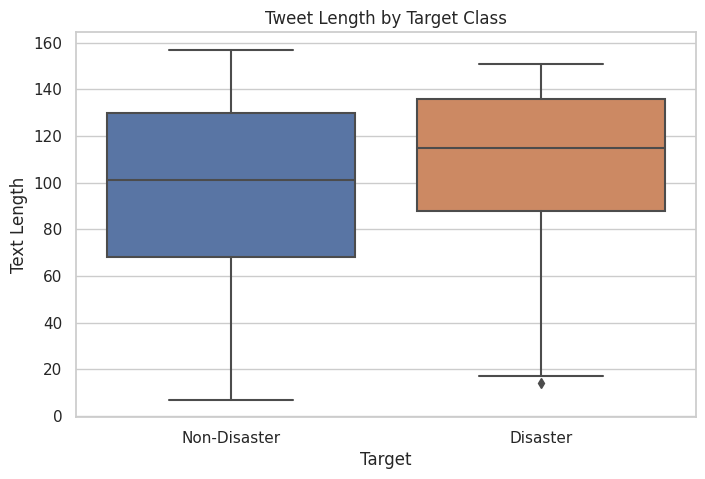

In [13]:
# Compare text length by target
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="target", y="text_length")
plt.title("Tweet Length by Target Class")
plt.xlabel("Target")
plt.ylabel("Text Length")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

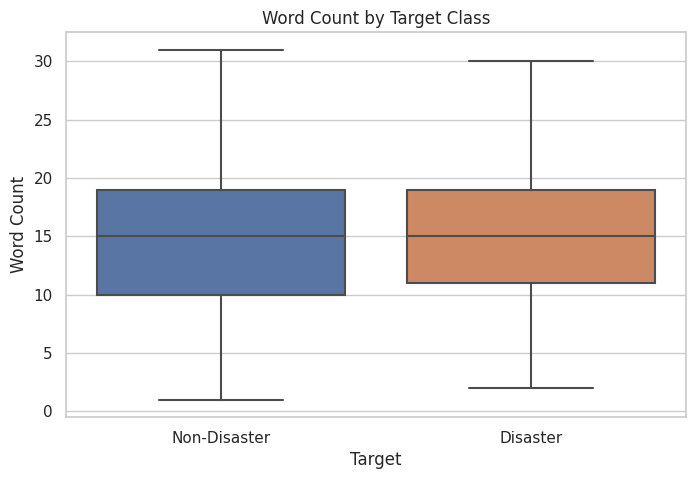

In [14]:
# Compare word count by target
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_df, x="target", y="word_count")
plt.title("Word Count by Target Class")
plt.xlabel("Target")
plt.ylabel("Word Count")
plt.xticks(ticks=[0, 1], labels=["Non-Disaster", "Disaster"])
plt.show()

In [15]:
# Average text length and word count by target
length_summary = train_df.groupby("target")[["text_length", "word_count"]].mean().round(2)
length_summary

,text_length,word_count
target,,
0,95.71,14.70
1,108.11,15.17


In [16]:
# Check most frequent keywords
keyword_summary = train_df["keyword"].value_counts().head(15)
keyword_summary

keyword
fatalities     45
deluge         42
armageddon     42
sinking        41
damage         41
harm           41
body%20bags    41
outbreak       40
evacuate       40
fear           40
collided       40
siren          40
twister        40
windstorm      40
sinkhole       39
Name: count, dtype: int64

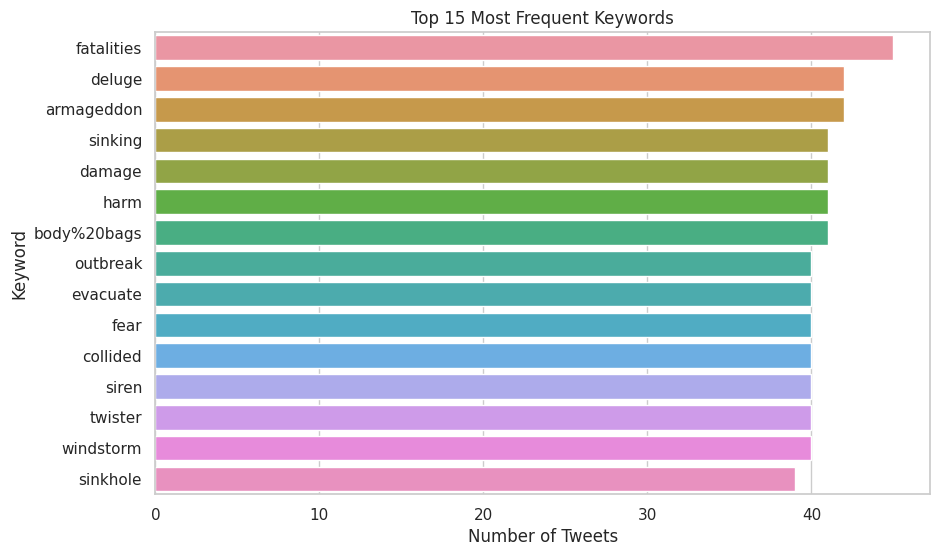

In [17]:
# Plot most frequent keywords
plt.figure(figsize=(10, 6))
sns.barplot(x=keyword_summary.values, y=keyword_summary.index)
plt.title("Top 15 Most Frequent Keywords")
plt.xlabel("Number of Tweets")
plt.ylabel("Keyword")
plt.show()

### Exploratory Data Analysis Insights

The dataset contains slightly more non-disaster tweets than disaster-related tweets, although the class distribution remains reasonably balanced.

Several patterns can be observed from the exploratory analysis:

- Disaster-related tweets tend to contain longer text on average.
- Word count distributions are relatively similar across both classes.
- The dataset contains a variety of disaster-related keywords such as `fatalities`, `deluge`, and `armageddon`.
- Since keyword frequencies are relatively evenly distributed, the semantic content of the tweet text is expected to play a larger role during classification.

These observations suggest that text preprocessing and feature extraction will be important for improving model performance.

## 🧹 Text Preprocessing

In [18]:
# Import NLP libraries
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Error loading punkt: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>
[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


False

In [19]:
# Initialize preprocessing tools
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

In [20]:
# Define text preprocessing function
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol only
    text = re.sub(r"#", "", text)

    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenize text
    tokens = word_tokenize(text)

    # Remove stopwords and apply stemming
    processed_tokens = [
        stemmer.stem(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(processed_tokens)

In [21]:
# Apply preprocessing
train_df["clean_text"] = train_df["text"].apply(preprocess_text)
test_df["clean_text"] = test_df["text"].apply(preprocess_text)

In [22]:
# Compare original and cleaned text
comparison_df = pd.DataFrame({
    "original_text": train_df["text"].head(5),
    "clean_text": train_df["clean_text"].head(5)
})

comparison_df

,original_text,clean_text
0,Our Deeds are the Reason of this #earthquake May ALLAH Forgive us all,deed reason earthquak may allah forgiv
1,Forest fire near La Ronge Sask. Canada,forest fire near rong sask canada
2,All residents asked to 'shelter in place' are being notified by officers. No other evacuation or shelter in place or...,resid ask shelter place notifi offic evacu shelter place order expect
3,"13,000 people receive #wildfires evacuation orders in California",peopl receiv wildfir evacu order california
4,Just got sent this photo from Ruby #Alaska as smoke from #wildfires pours into a school,got sent photo rubi alaska smoke wildfir pour school


In [23]:
# Check for empty cleaned texts
empty_cleaned_texts = (train_df["clean_text"].str.strip() == "").sum()

print("Empty cleaned texts:", empty_cleaned_texts)

Empty cleaned texts: 3


In [24]:
# Inspect empty cleaned texts
empty_cleaned_rows = train_df[train_df["clean_text"].str.strip() == ""]

empty_cleaned_rows[["text", "target"]]

,text,target
3663,@Truly_Stings Yo Dm me,1
4497,@Hurricane_Dame ???????? I don't have them they out here,1
6766,@Ayshun_Tornado then don't,0


In [25]:
# Replace empty cleaned texts with a placeholder token
train_df["clean_text"] = train_df["clean_text"].replace("", "emptytweet")
test_df["clean_text"] = test_df["clean_text"].replace("", "emptytweet")

print("Empty cleaned texts after replacement:", (train_df["clean_text"].str.strip() == "").sum())

Empty cleaned texts after replacement: 0


### Text Preprocessing

The raw tweet text contains hashtags, mentions, punctuation, URLs, and other noisy patterns that are common in social media data. Before training the model, the text was cleaned and standardized using several preprocessing steps:

- Converted text to lowercase
- Removed URLs and user mentions
- Removed punctuation and numbers
- Tokenized text into individual words
- Removed stopwords
- Applied stemming using Porter Stemmer

The preprocessing step helps reduce noise while preserving important semantic information for classification.

A small number of tweets became empty after preprocessing because they mainly contained mentions, symbols, or stopwords. These rows were replaced with a placeholder token to avoid issues during vectorization.

## 🤖 Model Development and Evaluation

In [26]:
# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [27]:
# Define features and target
X = train_df["clean_text"]
y = train_df["target"]

In [28]:
# Split dataset into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Validation set size:", X_valid.shape[0])

Training set size: 6090
Validation set size: 1523


In [29]:
# Initialize TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [30]:
# Transform text data into TF-IDF features
X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_valid_tfidf.shape)

Training TF-IDF shape: (6090, 5000)
Validation TF-IDF shape: (1523, 5000)


In [31]:
# Preview some TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

feature_names[:30]

array(['aba', 'aba woman', 'abandon', 'abandon aircraft', 'abbott',
       'abbswinston', 'abbswinston zionist', 'abc', 'abc news', 'abil',
       'abl', 'ablaz', 'abort', 'absolut', 'abstorm', 'abus', 'accept',
       'access', 'access secret', 'accid', 'accid expert', 'accid indian',
       'accid man', 'accid properti', 'accident', 'accord', 'account',
       'account hiroshima', 'accus', 'accus nema'], dtype=object)

In [32]:
# Import model and evaluation libraries
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [33]:
# Train baseline Naive Bayes model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

In [34]:
# Generate validation predictions
y_pred_nb = nb_model.predict(X_valid_tfidf)

In [35]:
# Evaluate baseline Naive Bayes model
nb_accuracy = accuracy_score(y_valid, y_pred_nb)
nb_precision = precision_score(y_valid, y_pred_nb)
nb_recall = recall_score(y_valid, y_pred_nb)
nb_f1 = f1_score(y_valid, y_pred_nb)

print("Baseline Naive Bayes Performance")
print("-" * 40)
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1-Score : {nb_f1:.4f}")

Baseline Naive Bayes Performance
----------------------------------------
Accuracy : 0.8188
Precision: 0.8780
Recall   : 0.6713
F1-Score : 0.7608


In [36]:
# Classification report
print(classification_report(y_valid, y_pred_nb, target_names=["Non-Disaster", "Disaster"]))

              precision    recall  f1-score   support

Non-Disaster       0.79      0.93      0.85       869
    Disaster       0.88      0.67      0.76       654

    accuracy                           0.82      1523
   macro avg       0.83      0.80      0.81      1523
weighted avg       0.83      0.82      0.81      1523



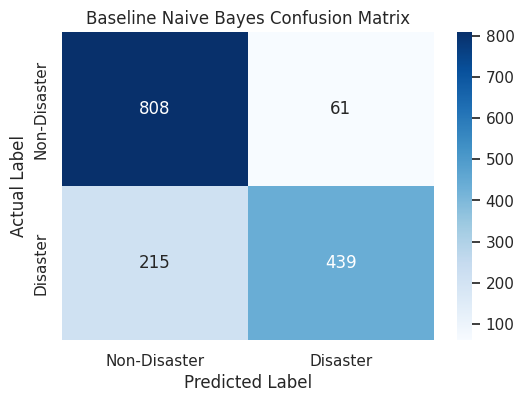

In [37]:
# Confusion matrix
cm_nb = confusion_matrix(y_valid, y_pred_nb)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Disaster", "Disaster"],
    yticklabels=["Non-Disaster", "Disaster"]
)
plt.title("Baseline Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

### Baseline Naive Bayes Results

The baseline Multinomial Naive Bayes model achieved solid overall performance on the validation dataset, reaching an accuracy of approximately 82%.

The model performed especially well in identifying non-disaster tweets, while maintaining high precision for disaster-related tweets. However, recall for the disaster class was lower, indicating that some disaster-related tweets were still missed during prediction.

This behaviour suggests that the model is relatively conservative when classifying tweets as disasters. In real-world applications, this tradeoff could reduce false alarms but may also increase the risk of missing genuine emergency-related content.

Overall, the baseline model provides a strong starting point for further optimisation and comparison with other machine learning approaches.

## ⚖️ Baseline Model Comparison

In [38]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [39]:
# Train Logistic Regression model
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [40]:
# Generate validation predictions
y_pred_lr = lr_model.predict(X_valid_tfidf)

In [41]:
# Evaluate Logistic Regression model
lr_accuracy = accuracy_score(y_valid, y_pred_lr)
lr_precision = precision_score(y_valid, y_pred_lr)
lr_recall = recall_score(y_valid, y_pred_lr)
lr_f1 = f1_score(y_valid, y_pred_lr)

print("Logistic Regression Performance")
print("-" * 40)
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1-Score : {lr_f1:.4f}")

Logistic Regression Performance
----------------------------------------
Accuracy : 0.8273
Precision: 0.8574
Recall   : 0.7171
F1-Score : 0.7810


In [42]:
# Classification report
print(classification_report(y_valid, y_pred_lr, target_names=["Non-Disaster", "Disaster"]))

              precision    recall  f1-score   support

Non-Disaster       0.81      0.91      0.86       869
    Disaster       0.86      0.72      0.78       654

    accuracy                           0.83      1523
   macro avg       0.83      0.81      0.82      1523
weighted avg       0.83      0.83      0.82      1523



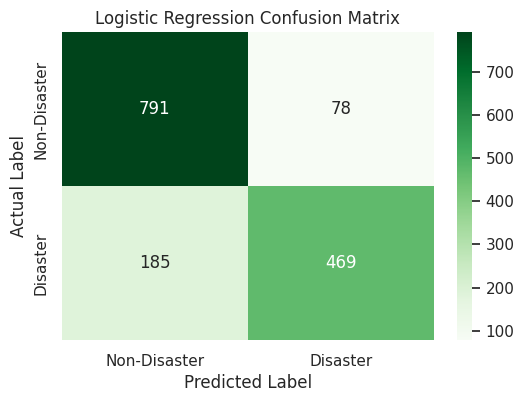

In [43]:
# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_valid, y_pred_lr)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Non-Disaster", "Disaster"],
    yticklabels=["Non-Disaster", "Disaster"]
)
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [44]:
# Compare model performance
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Logistic Regression"],
    "Accuracy": [nb_accuracy, lr_accuracy],
    "Precision": [nb_precision, lr_precision],
    "Recall": [nb_recall, lr_recall],
    "F1-Score": [nb_f1, lr_f1]
})

comparison_df.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.827315,0.857404,0.717125,0.781016
0,Naive Bayes,0.818779,0.878000,0.671254,0.760832


### Baseline Model Comparison

To better understand model performance, Logistic Regression was introduced as a baseline comparison against the Multinomial Naive Bayes classifier.

The Logistic Regression model achieved slightly better overall performance, particularly in recall and F1-score. This suggests that Logistic Regression was more effective at identifying disaster-related tweets while maintaining strong precision.

In contrast, the Naive Bayes model produced fewer false positives, resulting in slightly higher precision. However, it missed more actual disaster tweets compared to Logistic Regression.

Overall, Logistic Regression provided a more balanced classification performance on the validation dataset and will serve as a stronger benchmark for further experimentation.

## 🎯 Hyperparameter Tuning

In [45]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

In [46]:
# Define parameter grid
param_grid = {
    "alpha": [0.1, 0.3, 0.5, 0.7, 1.0]
}

In [47]:
# Initialize GridSearchCV
grid_search_nb = GridSearchCV(
    estimator=MultinomialNB(),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

In [48]:
# Train tuned Naive Bayes model
grid_search_nb.fit(X_train_tfidf, y_train)

GridSearchCV(cv=5, estimator=MultinomialNB(), n_jobs=-1,
             param_grid={'alpha': [0.1, 0.3, 0.5, 0.7, 1.0]}, scoring='f1')

In [49]:
# Best parameters
print("Best Parameters:", grid_search_nb.best_params_)
print("Best Cross-Validation F1:", round(grid_search_nb.best_score_, 4))

Best Parameters: {'alpha': 0.5}
Best Cross-Validation F1: 0.7349


In [50]:
# Get best tuned model
tuned_nb_model = grid_search_nb.best_estimator_

In [51]:
# Generate predictions using tuned model
y_pred_tuned_nb = tuned_nb_model.predict(X_valid_tfidf)

In [52]:
# Evaluate tuned Naive Bayes model
tuned_nb_accuracy = accuracy_score(y_valid, y_pred_tuned_nb)
tuned_nb_precision = precision_score(y_valid, y_pred_tuned_nb)
tuned_nb_recall = recall_score(y_valid, y_pred_tuned_nb)
tuned_nb_f1 = f1_score(y_valid, y_pred_tuned_nb)

print("Tuned Naive Bayes Performance")
print("-" * 40)
print(f"Accuracy : {tuned_nb_accuracy:.4f}")
print(f"Precision: {tuned_nb_precision:.4f}")
print(f"Recall   : {tuned_nb_recall:.4f}")
print(f"F1-Score : {tuned_nb_f1:.4f}")

Tuned Naive Bayes Performance
----------------------------------------
Accuracy : 0.8162
Precision: 0.8696
Recall   : 0.6728
F1-Score : 0.7586


In [53]:
# Updated comparison table
comparison_df = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Tuned Naive Bayes"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        tuned_nb_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision,
        tuned_nb_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall,
        tuned_nb_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1,
        tuned_nb_f1
    ]
})

comparison_df.sort_values(by="F1-Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1-Score
1,Logistic Regression,0.827315,0.857404,0.717125,0.781016
0,Naive Bayes,0.818779,0.878000,0.671254,0.760832
2,Tuned Naive Bayes,0.816152,0.869565,0.672783,0.758621


### Hyperparameter Tuning Results

Grid search was used to tune the smoothing parameter (`alpha`) for the Multinomial Naive Bayes model using cross-validation and F1-score as the optimisation metric.

The best-performing configuration used an alpha value of 0.5. However, the tuned model produced only marginal differences compared to the baseline Naive Bayes model and did not outperform Logistic Regression on the validation dataset.

This result highlights an important practical observation in machine learning: hyperparameter tuning does not always guarantee better performance. In this case, the Logistic Regression model continued to provide the strongest balance between precision and recall.

## 🔍 Model Interpretation and Error Analysis

In [54]:
# Extract Logistic Regression feature importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": lr_model.coef_[0]
})

In [55]:
# Top positive words
top_positive_words = feature_importance.sort_values(
    by="coefficient",
    ascending=False
).head(15)

top_positive_words

,feature,coefficient
2077,hiroshima,3.480120
2367,kill,2.874285
1667,fire,2.838470
4864,wildfir,2.724813
4216,storm,2.575469
679,california,2.533805
1355,earthquak,2.473354
1469,evacu,2.438892
1711,flood,2.399334
4263,suicid,2.172127


In [56]:
# Top negative words
top_negative_words = feature_importance.sort_values(
    by="coefficient",
    ascending=True
).head(15)

top_negative_words

,feature,coefficient
2603,love,-2.233160
2494,let,-1.827048
2645,make,-1.716242
2953,new,-1.709485
4720,want,-1.687916
1797,fuck,-1.586515
333,bag,-1.545421
1996,harm,-1.545342
473,blew,-1.539067
1801,full,-1.529969


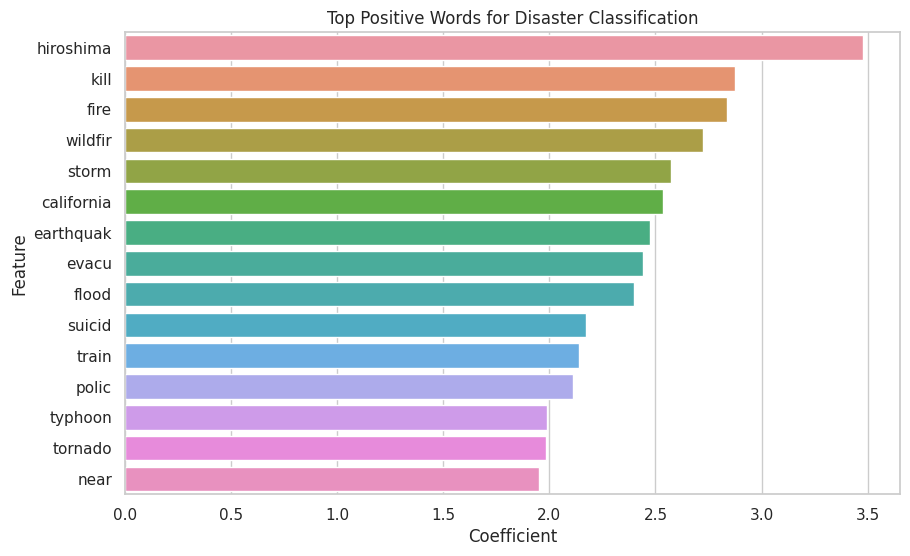

In [57]:
# Plot top positive words
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_positive_words,
    x="coefficient",
    y="feature"
)

plt.title("Top Positive Words for Disaster Classification")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

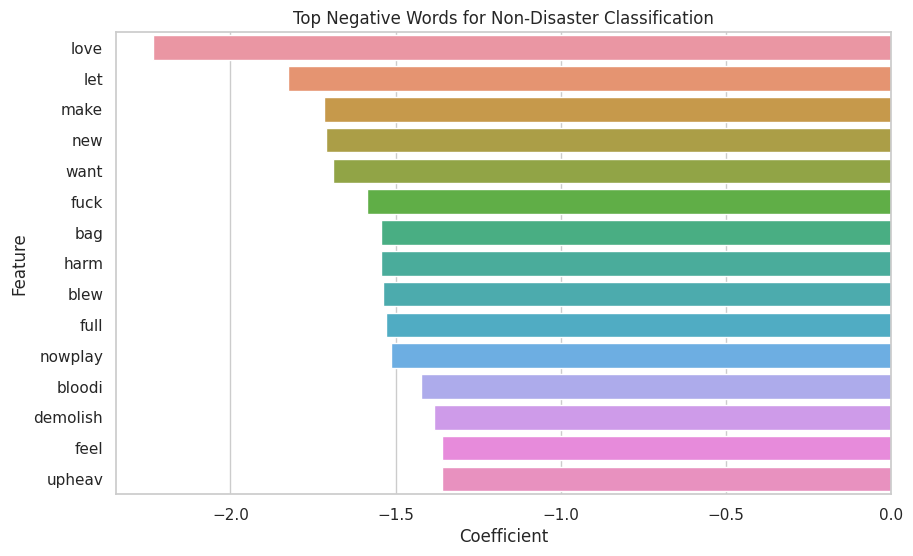

In [58]:
# Plot top negative words
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_negative_words,
    x="coefficient",
    y="feature"
)

plt.title("Top Negative Words for Non-Disaster Classification")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

### Feature Importance Analysis

The Logistic Regression model provides interpretable coefficients that help identify which words contribute most strongly toward each prediction class.

Words such as `hiroshima`, `wildfir`, `earthquak`, and `flood` were strongly associated with disaster-related tweets. These terms are directly related to emergencies, natural disasters, and crisis events, making them strong predictive indicators for the positive class.

On the other hand, words such as `love`, `make`, `want`, and `feel` were more strongly associated with non-disaster tweets. These terms commonly appear in casual conversations, entertainment content, or everyday social media interactions.

This type of interpretability is useful because it allows us to understand how the model makes decisions instead of treating the classifier as a black box.

In [59]:
# Display misclassified examples
misclassified_df = pd.DataFrame({
    "text": X_valid,
    "actual": y_valid,
    "predicted": y_pred_lr
})

misclassified_df = misclassified_df[
    misclassified_df["actual"] != misclassified_df["predicted"]
]

misclassified_df.head(10)

,text,actual,predicted
4863,step one get mass murder portrait yuan,0,1
6837,hollywood movi trap miner releas chile hollywood movi trap miner star,1,0
2905,drown demon know swim,1,0
1956,need plant pacif cyclon season would help,1,0
1358,firefight act like cop drive around shoot flamethrow burn build,0,1
5020,look like mudslid poor thing greatbritishbakeoff,1,0
6006,agre certain cultur appropri thing honestli look hous scream appropri buddha stuff,1,0
3441,dress meme offici explod internet,1,0
6488,aquarium ornament wreck sail boat sunk ship destroy fish tank cave decor full read,1,0
5267,slicker oil spill,0,1


### Error Analysis

Several misclassified tweets reveal common limitations of traditional NLP models.

Some tweets contained disaster-related words such as `explod`, `wreck`, or `oil spill`, but were actually used in casual or metaphorical contexts. In these cases, the model incorrectly classified non-disaster tweets as disaster-related content.

Other tweets referenced real disaster events using indirect language, sarcasm, or ambiguous wording, making them harder for the model to classify correctly.

These examples highlight an important limitation of classical machine learning approaches for NLP: the models rely heavily on word patterns and may struggle to fully understand context, tone, or semantic meaning.

## 📌 Final Conclusions and Recommendations

### Business Recommendations

This project demonstrates how classical NLP techniques can be used to build an interpretable tweet classification system for disaster-related content.

Potential real-world applications include:

- Social media monitoring systems
- Emergency response support tools
- Public sentiment tracking
- Early-stage crisis detection pipelines

The Logistic Regression model provided the strongest balance between precision and recall, making it a more suitable baseline model for practical deployment compared to Naive Bayes.

However, the error analysis also shows that traditional machine learning models still struggle with sarcasm, figurative language, and contextual understanding. For more advanced production-level systems, transformer-based NLP models such as BERT or DistilBERT could further improve classification performance.

### Final Conclusion

This project explored tweet sentiment classification using classical NLP and machine learning techniques.

The workflow covered:
- exploratory data analysis
- text preprocessing
- TF-IDF feature extraction
- baseline model comparison
- hyperparameter tuning
- model interpretation
- error analysis

Among the evaluated models, Logistic Regression achieved the best overall balance between precision, recall, and F1-score on the validation dataset.

Overall, the project demonstrates how lightweight and interpretable NLP pipelines can still provide strong baseline performance for text classification tasks while remaining computationally efficient and easy to explain.